# Лаба 9

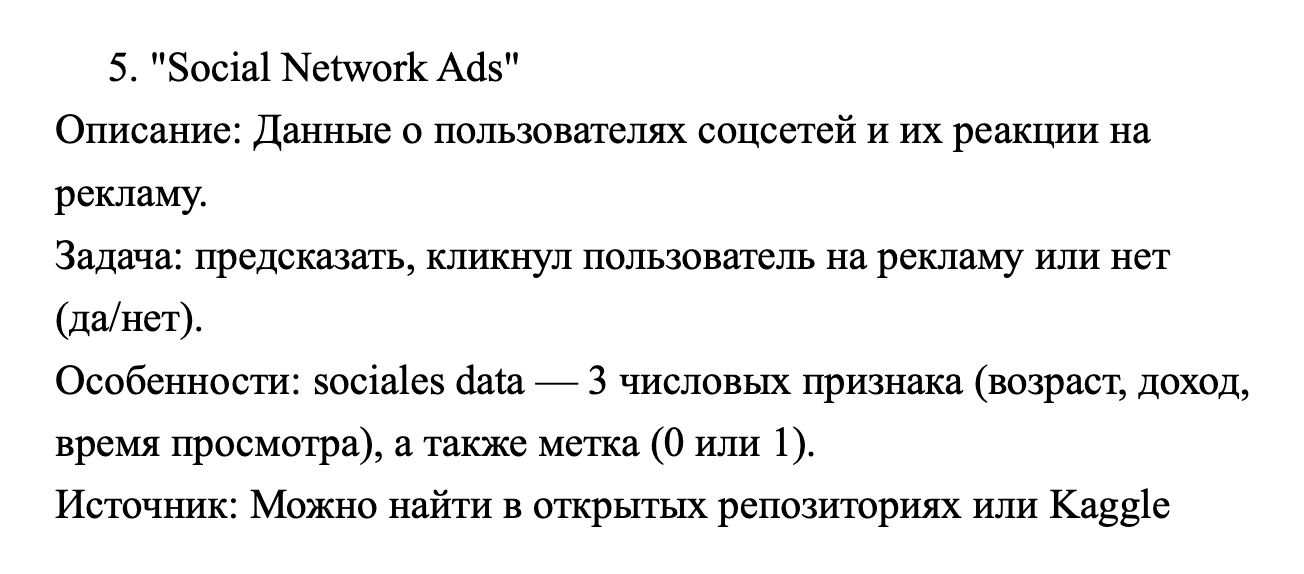

[скачал с Kaggle](https://www.kaggle.com/datasets/mdwasimakhtar03/social-network-adscsv?resource=download)

# Задания

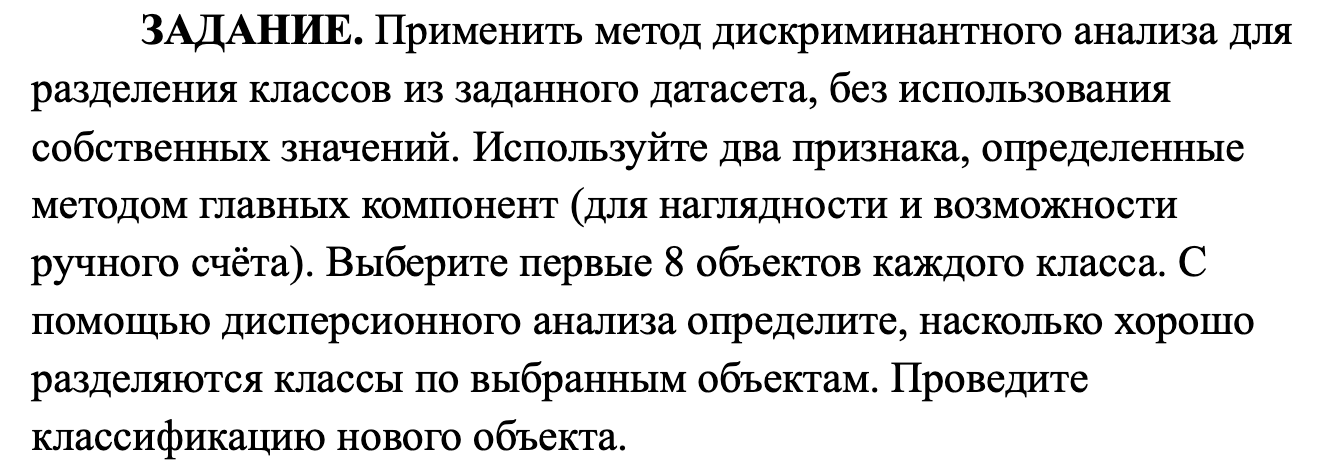

# Теория

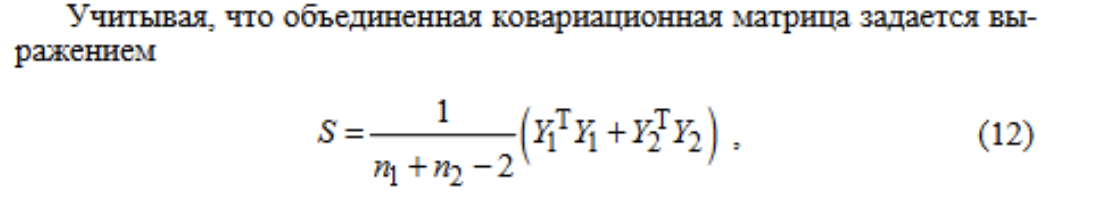

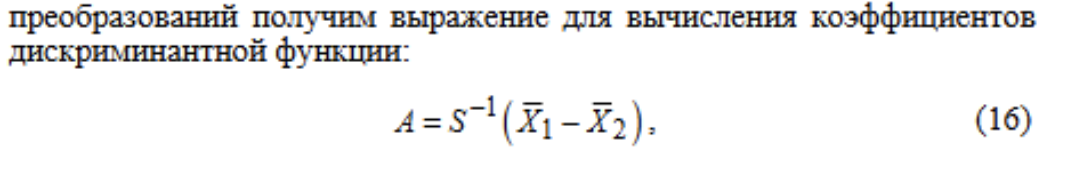

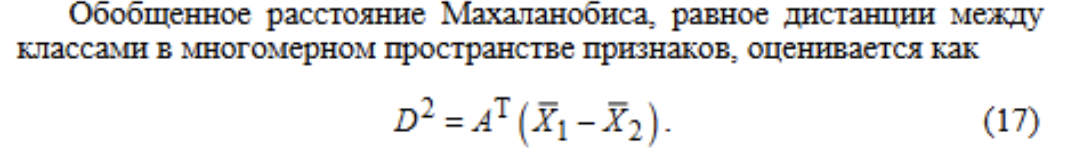

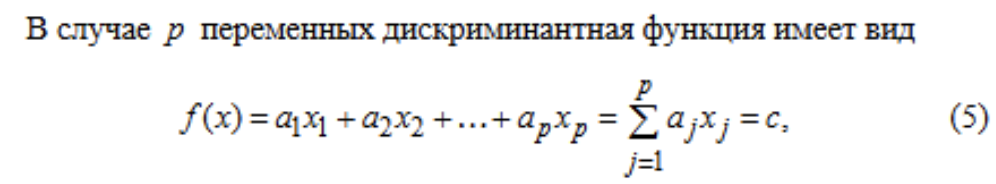

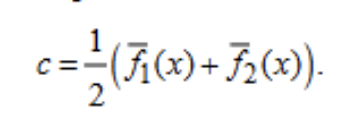

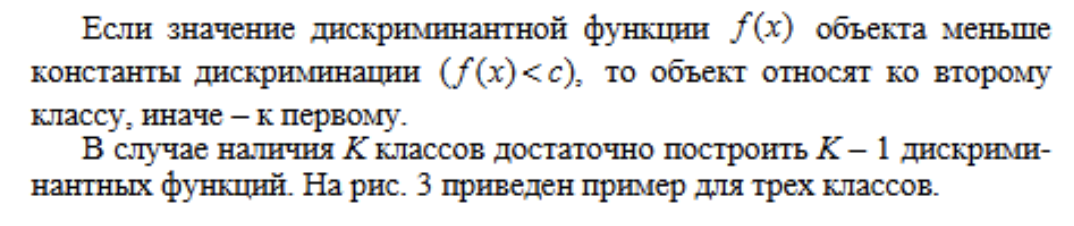

![Снимок экрана 2026-05-06 в 19.39.08.png](<attachment:Снимок экрана 2026-05-06 в 19.39.08.png>)

![Снимок экрана 2026-05-06 в 19.39.56.png](<attachment:Снимок экрана 2026-05-06 в 19.39.56.png>)
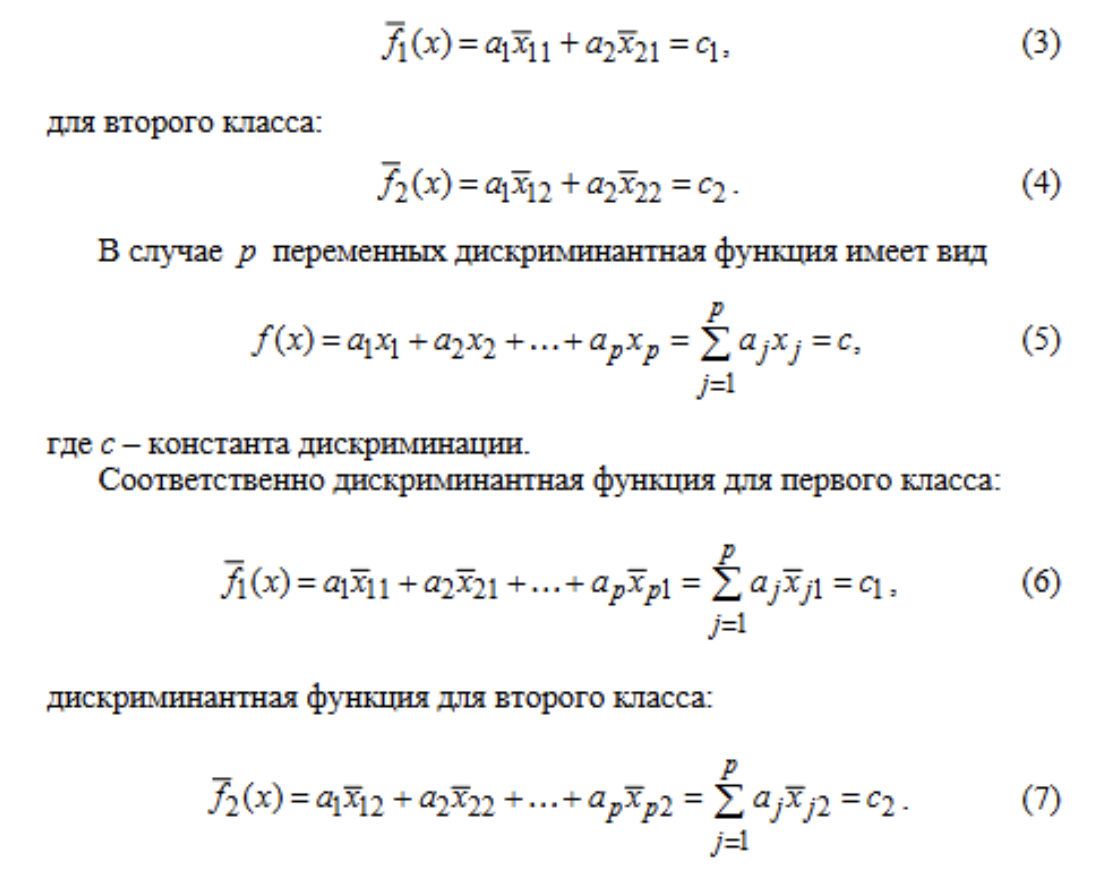
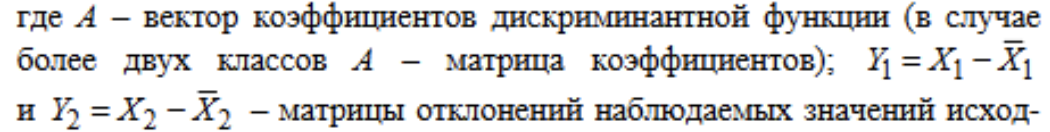

# Подготовка данных

данные не изменились. их надо стандартизировать, как в предыдущей лабораторной работе

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# загружаем
df = pd.read_csv('data/Social_Network_Ads.csv')
X = df[['Age', 'EstimatedSalary']] # главные 
y = df['Purchased'] # целевой

# стандартизируем
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# просто для удобства работы с данными
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Class'] = y

# первые 8 объектов каждого класса
# не купил
class_0_data = df_pca[df_pca['Class'] == 0].head(8)
# купил
class_1_data = df_pca[df_pca['Class'] == 1].head(8)

# объединяем в один датасет (16 строк получается)
df_work = pd.concat([class_0_data, class_1_data]).reset_index(drop=True)

print("--- первые 8 объектов каждого класса ---")
print(df_work)
print(f"\nразмерность рабочей выборки получилась: {df_work.shape}")

--- Рабочая выборка (первые 8 объектов каждого класса) ---
         PC1       PC2  Class
0  -2.313543  0.206299      0
1  -1.212171 -0.853544      0
2  -1.342439  0.231872      0
3  -0.984204  0.455031      0
4  -1.129990  1.389852      0
5  -0.963440  0.475795      0
6  -0.423573  1.015661      0
7  -1.617618  0.091769      0
8   1.284547  2.048401      1
9  -0.297895 -1.560180      1
10 -0.412207 -1.404340      1
11 -0.303141 -1.430349      1
12 -0.147300 -1.544661      1
13 -0.495263 -1.487396      1
14  0.200443 -1.061842      1
15  0.101869 -1.295492      1

Размерность рабочей выборки: (16, 3)


# Дисперсионный анализ

сумма квадратов отклонений

![Снимок экрана 2026-05-06 в 19.44.10.png](<attachment:Снимок экрана 2026-05-06 в 19.44.10.png>)

межгрупповая вариация

![Снимок экрана 2026-05-06 в 19.44.26.png](<attachment:Снимок экрана 2026-05-06 в 19.44.26.png>)
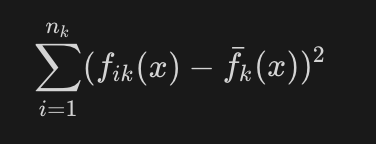
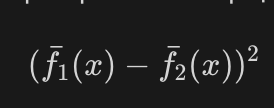

In [ ]:
import numpy as np

# выделяем по классам
group_0 = df_work[df_work['Class'] == 0]
group_1 = df_work[df_work['Class'] == 1]

n0 = len(group_0) # 8
n1 = len(group_1) # 8
N = n0 + n1       # 16
K = 2             # количество классов

# функция для ручного расчета F-статистики дисперсионного анализа
def calculate_anova_f(feature):
    x0 = group_0[feature].values
    x1 = group_1[feature].values
    x_all = df_work[feature].values
    
    # средние значения
    mean_0 = np.mean(x0)
    mean_1 = np.mean(x1)
    mean_all = np.mean(x_all)
    
    # (SSB - Sum of Squares Between)
    ssb = n0 * (mean_0 - mean_all)**2 + n1 * (mean_1 - mean_all)**2
    df_b = K - 1 # степени свободы
    msb = ssb / df_b # межгрупповая дисперсия
    
    # (SSW - Sum of Squares Within)
    ssw = np.sum((x0 - mean_0)**2) + np.sum((x1 - mean_1)**2)
    df_w = N - K # степени свободы
    msw = ssw / df_w # Внутригрупповая дисперсия
    
    # F-статистика
    f_stat = msb / msw
    return f_stat, msb, msw

# для первой 
f_pc1, msb1, msw1 = calculate_anova_f('PC1')
# для второй главной компоненты
f_pc2, msb2, msw2 = calculate_anova_f('PC2')

print("--- результаты дисперсионного анализа ---")
print(f"F-статистика-PC1 = {f_pc1:.4f}")
print(f"F-статистика-PC2 = {f_pc2:.4f}")

if f_pc1 > f_pc2:
    print("\nf_pc1 > f_pc2: PC1 разделяет лучше, ибо F-статистика выше.")
else:
    print("\nf_pc1 > f_pc2: PC2 разделяет лучше, ибо F-статистика выше.")

--- результаты дисперсионного анализа ---
F-статистика-PC1 = 19.3683
F-статистика-PC2 = 7.3966

f_pc1 > f_pc2: PC1 разделяет лучше, ибо F-статистика выше.


# Центроиды и объединенные ковариционные матрицы


In [5]:
import numpy as np
import pandas as pd

# числовые признаки (PC1, PC2) как numpy массивы
X0 = group_0[['PC1', 'PC2']].values
X1 = group_1[['PC1', 'PC2']].values

n0 = len(X0) # 8
n1 = len(X1) # 8

# Центроиды (среднее значение по столбцам)
mean_0 = np.mean(X0, axis=0)
mean_1 = np.mean(X1, axis=0)

print("--- Центроиды ---")
print(f"Центроид Класса 0: {mean_0.round(4)}")
print(f"Центроид Класса 1:    {mean_1.round(4)}\n")

# Матрицы отклонения
Y0 = X0 - mean_0
Y1 = X1 - mean_1

# суммы квадратов отклонений
W0 = Y0.T @ Y0
W1 = Y1.T @ Y1

# объединенная ковариационная матрица S
S = (W0 + W1) / (n0 + n1 - 2)

print("--- Объединенная ковариационная матрица S ---")
S_df = pd.DataFrame(S, columns=['PC1', 'PC2'], index=['PC1', 'PC2'])
print(S_df.round(4))

--- Центроиды ---
Центроид Класса 0: [-1.2484  0.3766]
Центроид Класса 1:    [-0.0086 -0.967 ]

--- Объединенная ковариационная матрица S ---
        PC1     PC2
PC1  0.3174  0.4009
PC2  0.4009  0.9762


# Дискриминантная функция

In [6]:
import numpy as np

# обратная ковариционная матрица S^-1
det_S = np.linalg.det(S)
print(f"--- проверим определитель S: {det_S:.4f} ---")

if det_S == 0:
    print(f"регулязируем {S + np.eye(2) * 0.01}")
    # Регуляризация (как на стр. 14 конспекта), если вдруг матрица вырождена
    S_inv = np.linalg.inv(S + np.eye(2) * 0.01)
else:
    S_inv = np.linalg.inv(S)

print("\n--- S^-1 ---")
print(pd.DataFrame(S_inv, columns=['PC1', 'PC2'], index=['PC1', 'PC2']).round(4))

# A = S^-1 * (mean_0 - mean_1)
mean_diff = mean_0 - mean_1
A = S_inv @ mean_diff

print("\n--- коэфф-ы дискриминантной функции (A) ---")
print(f"a1 (для PC1) = {A[0]:.4f}")
print(f"a2 (для PC2) = {A[1]:.4f}")
print(f"f(x) = {A[0]:.4f}*PC1 + {A[1]:.4f}*PC2")

# средние значения дискриминантной функции для каждого класса
f_mean_0 = np.dot(A, mean_0)
f_mean_1 = np.dot(A, mean_1)

print("\n--- значения f в центроидах ---")
print(f"Для 0 (f_mean_0): {f_mean_0:.4f}")
print(f"Для 1 (f_mean_1): {f_mean_1:.4f}")

# константа дискриминации c
c = (f_mean_0 + f_mean_1) / 2

print(f"\n--- константа дискриминации (c) ---")
print(f"c = {c:.4f}")

--- проверим определитель S: 0.1491 ---

--- S^-1 ---
        PC1     PC2
PC1  6.5457 -2.6882
PC2 -2.6882  2.1283

--- коэфф-ы дискриминантной функции (A) ---
a1 (для PC1) = -11.7268
a2 (для PC2) = 6.1923
f(x) = -11.7268*PC1 + 6.1923*PC2

--- значения f в центроидах ---
Для 0 (f_mean_0): 16.9714
Для 1 (f_mean_1): -5.8868

--- константа дискриминации (c) ---
c = 5.5423


# Классификация нового объекта

In [9]:
import numpy as np

# тест
new_user_raw = pd.DataFrame({'Age': [45], 'EstimatedSalary': [100000]})
new_user_scaled = scaler.transform(new_user_raw)
new_user_pca = pca.transform(new_user_scaled)

# коорд-ы в пространстве главных компонент
G = new_user_pca[0] 

print(f"--- G ---")
print(f"в пространстве PC1, PC2: {G.round(4)}\n")

# расстояния Махаланобиса до Класса 0
diff_0 = G - mean_0
D2_0 = diff_0.T @ S_inv @ diff_0

# расстояния Махаланобиса до Класса 1
diff_1 = G - mean_1
D2_1 = diff_1.T @ S_inv @ diff_1

print(f"--- квадраты расстояний Махаланобиса ---")
print(f"до Класса 0 (не купил): D^2_0 = {D2_0:.4f}")
print(f"до Класса 1 (купил):    D^2_1 = {D2_1:.4f}\n")

# классификация
print(f"--- итого ---")
if D2_0 < D2_1:
    print("min расстояние до Класса 0.")
    print("Пользователь скорее всего НЕ КЛИКНЕТ на рекламу")
else:
    print("min расстояние до Класса 1.")
    print("Пользователь скорее всего КЛИКНЕТ на рекламу")


f_G = np.dot(A, G)
print("\n--- через f(x) и константу c ---")
print(f"Значение f(G) = {f_G:.4f}")
print(f"Константа дискриминации c = {c:.4f}")

# так как мы считали A = S^-1 * (mean_0 - mean_1), значения для Класса 0 будут больше c.
if f_G > c:
    print("f(G) > c  =>  Класс 0")
else:
    print("f(G) < c  =>  Класс 1")

--- G ---
в пространстве PC1, PC2: [1.1243 0.1322]

--- квадраты расстояний Махаланобиса ---
до Класса 0 (не купил): D^2_0 = 40.0953
до Класса 1 (купил):    D^2_1 = 4.2781

--- итого ---
min расстояние до Класса 1.
Пользователь скорее всего КЛИКНЕТ на рекламу

--- через f(x) и константу c ---
Значение f(G) = -12.3663
Константа дискриминации c = 5.5423
f(G) < c  =>  Класс 1
